# Generating Correlation functions of strings

In [2]:
import sys
import numpy as np
sys.path.append("../../../src")
import kibble_zurek as kz
from common_imports import *
data = np.load("../data/data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz", allow_pickle=True)
taus, L, t, states = data["taus"], data["L"], data["t"], data["states"]


In [8]:
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np

n = 2
r_max = 100
r = np.arange(0, r_max )

# --- Parallelized computation ---
def compute_PP_for_state(state):
    return [kz.P_n_correlations(n, ri, state) for ri in r]

PP = np.array(
    Parallel(n_jobs=-1)(
        delayed(compute_PP_for_state)(state) for state in tqdm(states, desc="Computing Pn correlations")
    )
)

P = np.array([kz.P_n(n, state) for state in states])
PP_corr = PP - P[:, None]**2

# --- Save all data together ---
filename = f"../data/data_Pn_corr_n{n}_rmin_0_rmax{r_max}.npz"
np.savez_compressed(
    filename,
    n=n,
    r_max=r_max,
    r=r,
    PP=PP,
    P=P,
    PP_corr=PP_corr
)


Computing Pn correlations: 100%|██████████| 100/100 [02:46<00:00,  1.66s/it]


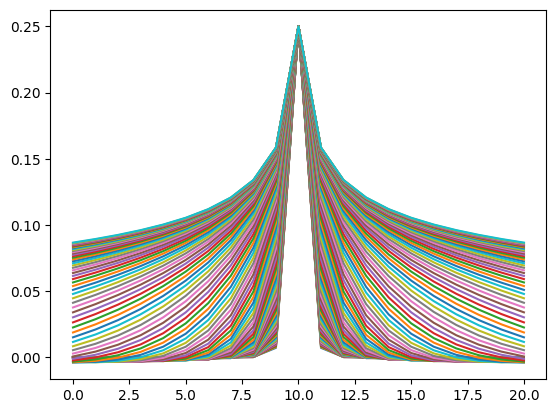

In [ ]:
data = np.load(filename, allow_pickle=True)
n, r_max, r, PP, P, PP_corr = data["n"], data["r_max"], data["r"], data["PP"], data["P"], data["PP_corr"]


IndexError: boolean index did not match indexed array along axis 0; size of axis is 100 but size of corresponding boolean axis is 20